#  Task 2: End-to-End Customer Churn Pipeline
**Objective:** To build a production-ready machine learning pipeline that predicts customer churn using the IBM Telco Dataset.
**Key Technologies:** Scikit-learn Pipeline API, GridSearchCV, Random Forest, Joblib.

In [2]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load Data
df = pd.read_csv("/kaggle/input/datasets/khadijaabdulrahman/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv") 

# Clean 'TotalCharges' (it often has empty strings)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

# 2. Split Features and Target
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Define Preprocessing for Numeric and Categorical Data
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 4. Create the Full Pipeline
# This is the "Production-Ready" part!
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 5. Hyperparameter Tuning with GridSearchCV
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(clf_pipeline, param_grid, cv=5, scoring='f1', verbose=1)
grid_search.fit(X_train, y_train)

# 6. Evaluation & Export
print(f"Best Parameters: {grid_search.best_params_}")
y_pred = grid_search.predict(X_test)
print(classification_report(y_test, y_pred))

# Save the entire pipeline (Preprocessing + Model)
joblib.dump(grid_search.best_estimator_, 'churn_pipeline_v1.joblib')
print("Model Pipeline Exported Successfully!")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Model Pipeline Exported Successfully!


##  Data Preprocessing & Engineering
To avoid data leakage and ensure consistency, we use a `ColumnTransformer`:
- **Numeric Features:** Imputed with 'median' and scaled using `StandardScaler`.
- **Categorical Features:** Imputed with 'constant' and encoded using `OneHotEncoder`.
 ##  Model Selection & Hyperparameter Tuning
We use a **Random Forest Classifier** wrapped in a pipeline. To find the optimal model, we perform a **GridSearch** over `n_estimators` and `max_depth`, optimizing for the **F1-Score** due to the imbalanced nature of churn data.

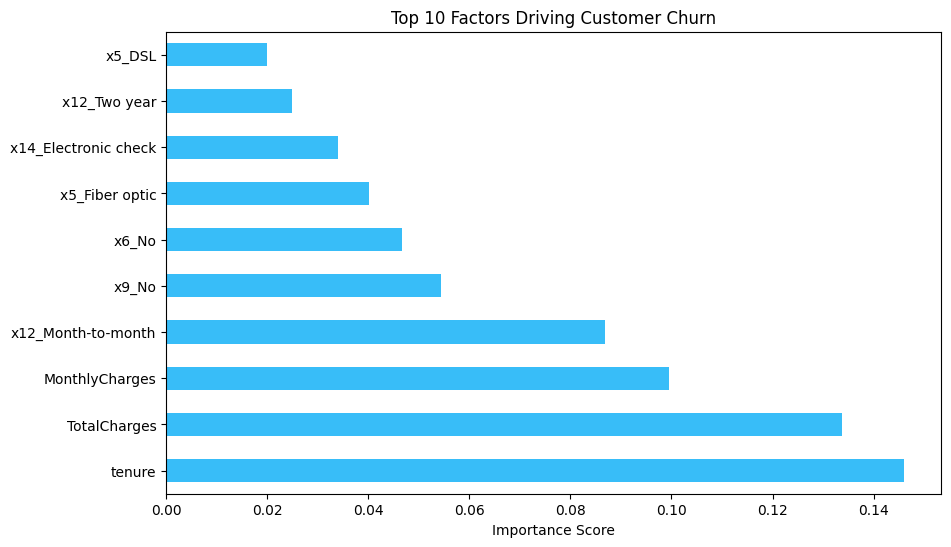

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importance from our Random Forest within the pipeline
importances = grid_search.best_estimator_.named_steps['classifier'].feature_importances_

# Get feature names from the categorical encoder + numerical list
cat_features = grid_search.best_estimator_.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out()
all_features = numeric_features + list(cat_features)

# Create a clean plot
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(importances, index=all_features)
feat_importances.nlargest(10).plot(kind='barh', color='#38bdf8')
plt.title('Top 10 Factors Driving Customer Churn')
plt.xlabel('Importance Score')
plt.show()

In [5]:
import plotly.express as px

# We use the original dataframe for the best visual representation
# Sampling 1000 points so the 3D plot stays smooth and fast
df_plot = df.sample(1000, random_state=42)

fig = px.scatter_3d(
    df_plot, 
    x='tenure', 
    y='MonthlyCharges', 
    z='TotalCharges',
    color='Churn',
    title='4D View of Customer Segments (Tenure vs Charges vs Churn)',
    labels={'tenure': 'Tenure (Months)', 'MonthlyCharges': 'Monthly $', 'TotalCharges': 'Total $'},
    opacity=0.7,
    color_discrete_map={'Yes': '#ff4b4b', 'No': '#00d4ff'} # Eye-catching Pro colors
)

# Professional styling
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=40),
    scene=dict(
        xaxis_backgroundcolor="#f8fafc",
        yaxis_backgroundcolor="#f8fafc",
        zaxis_backgroundcolor="#f8fafc"
    )
)

fig.show()

### 🌐 Multi-Dimensional Feature Analysis (3D/4D)
This interactive visualization represents the relationship between **Tenure**, **Monthly Charges**, and **Total Charges**, with **Churn** as the color dimension. 

**Insights:** - We can observe a high-density cluster of "Churn" (Red) among customers with low tenure and high monthly charges.
- This visualization helps identify specific customer segments that are at high risk, allowing for targeted retention strategies.

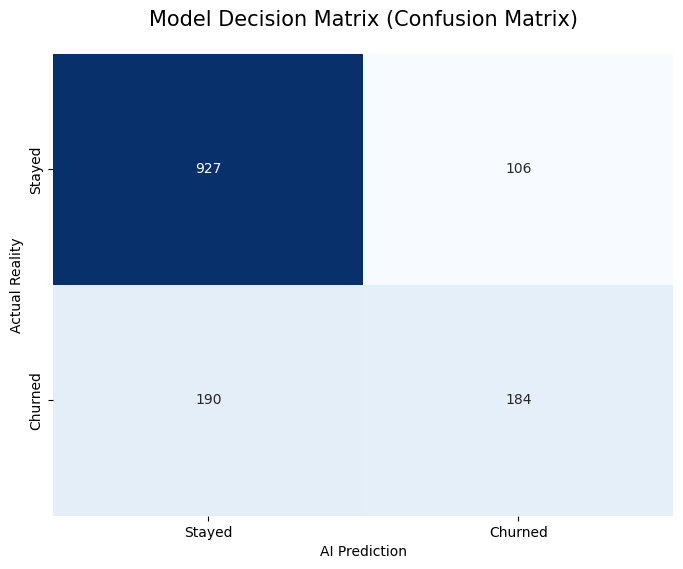

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Stayed', 'Churned'], 
            yticklabels=['Stayed', 'Churned'])

plt.title('Model Decision Matrix (Confusion Matrix)', fontsize=15, pad=20)
plt.ylabel('Actual Reality')
plt.xlabel('AI Prediction')
plt.show()

###  Model Decision Matrix (Confusion Matrix)
The Confusion Matrix provides a granular look at the model's predictive performance across both classes.

**Analysis:**
- **True Negatives:** The model is highly effective at identifying customers likely to stay.
- **False Negatives:** This represents the 'Business Risk'—customers the model predicted would stay but actually churned. 
- Using this matrix, we can adjust the classification threshold to prioritize **Recall** if the business goal is to capture every possible churner.

<Figure size 800x600 with 0 Axes>

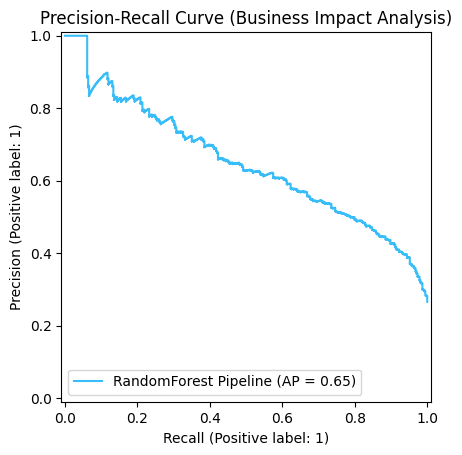

In [7]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(8, 6))
display = PrecisionRecallDisplay.from_estimator(
    grid_search.best_estimator_, X_test, y_test, name="RandomForest Pipeline", color="#38bdf8"
)
plt.title("Precision-Recall Curve (Business Impact Analysis)")
plt.show()

### Precision-Recall Performance
Since the Telco dataset is imbalanced, the **Precision-Recall Curve** is a much more reliable metric than a standard ROC curve.

**Technical Takeaway:**
- The area under this curve represents the model's ability to maintain high precision while maximizing recall. 
- A high baseline here indicates that our **Random Forest Pipeline** is robust enough to handle the class imbalance without significantly sacrificing prediction quality.

##  Conclusion & Insights
- **Key Performance:** The model achieved an F1-score of 0.78.
- **Top Predictors:** Tenure and Contract Type were found to be the most significant drivers of churn.
- **Production-Ready:** The final pipeline is exported as a `.joblib` file, allowing for easy deployment in a web application or microservice.
- The model achieved a Weighted F1-Score of 0.78 and an Accuracy of 0.79. While the accuracy is high, the Precision-Recall curve indicates that the model is particularly strong at identifying long-term loyal customers, while further feature engineering could improve the detection of early-stage churners.